In [1]:
from polygon import RESTClient
import pandas as pd
import numpy as np
import sklearn
import scipy
import matplotlib.pyplot as plt
import collections

import datetime

from tqdm import tqdm

from constants import api_key

import time

client = RESTClient(api_key = api_key)

import pyspark

In [2]:
spark = (
    pyspark
    .sql
    .SparkSession
    .builder
    .appName('sparksession')
    .config("spark.driver.memory", "8g")
    .config("spark.executor.memory", "16g")
    .config("spark.executor.cores", "4")
    .getOrCreate()
)


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
24/10/14 17:47:25 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
----------------------------------------
Exception occurred during processing of request from ('127.0.0.1', 52499)
Traceback (most recent call last):
  File "/Users/hiroku007/miniforge3/envs/algo_trading/lib/python3.12/socketserver.py", line 318, in _handle_request_noblock
    self.process_request(request, client_address)
  File "/Users/hiroku007/miniforge3/envs/algo_trading/lib/python3.12/socketserver.py", line 349, in process_request
    self.finish_request(request, client_address)
  File "/Users/hiroku007/miniforge3/envs/algo_trading/lib/python3.12/socketserver.py", line 362, in finish_request
    self.RequestHandlerClass(request, client_address, self)
  File "/Users/hiroku007/miniforge3/envs/algo_trading/lib/pytho

In [3]:
ticker = 'VIXY'
price_performance = collections.defaultdict(list)

for agg in tqdm(client.list_aggs(ticker=ticker, multiplier=1, timespan="minute", from_="2022-10-15", to="2024-10-14", limit=50000)):
    if datetime.datetime.fromtimestamp(agg.timestamp/1000).time()>=datetime.time(9, 30) and datetime.datetime.fromtimestamp(agg.timestamp/1000).time()<=datetime.time(16,0):
        price_performance['Open'].append(agg.open)
        price_performance['Close'].append(agg.close)
        price_performance['high'].append(agg.high)
        price_performance['low'].append(agg.low)
        price_performance['volume'].append(agg.volume)
        price_performance['Datetime'].append(datetime.datetime.fromtimestamp(agg.timestamp/1000))
        price_performance['transactions'].append(agg.transactions)

ticker_hist = spark.createDataFrame(pd.DataFrame(price_performance))
ticker_hist = ticker_hist.withColumn("ticker", pyspark.sql.functions.lit(ticker))

ticker_hist = ticker_hist.withColumn(
    "Date", 
    pyspark.sql.functions.to_date(pyspark.sql.functions.col("Datetime"))
)
ticker_hist = ticker_hist.withColumn(
    "Time", 
    pyspark.sql.functions.date_format(
        pyspark.sql.functions.col("Datetime"),
        "HH:mm:ss"
    )
)

ticker_hist = ticker_hist.withColumn(
    "logOpen", pyspark.sql.functions.log("Open")
)

ticker_hist = ticker_hist.withColumn(
    "logClose", pyspark.sql.functions.log("Close")
)

ticker_hist = ticker_hist.withColumn(
    "logReturns", pyspark.sql.functions.log("Close")
)

ticker_hist = ticker_hist.withColumn(
    "logReturns", pyspark.sql.functions.col("logClose") - pyspark.sql.functions.col("logOpen")
)

tickers = pd.read_html(
    'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')[0]
print(tickers.head())

missed_tickers = []

for ticker in tqdm(tickers['Symbol']):
    try: 
        price_performance = collections.defaultdict(list)
        aggs = []
        for agg in client.list_aggs(ticker=ticker, multiplier=1, timespan="minute", from_="2022-10-15", to="2024-10-14", limit=50000):
            price_performance['Open'].append(agg.open)
            price_performance['Close'].append(agg.close)
            price_performance['high'].append(agg.high)
            price_performance['low'].append(agg.low)
            price_performance['volume'].append(agg.volume)
            price_performance['Datetime'].append(datetime.datetime.fromtimestamp(agg.timestamp/1000))
            price_performance['transactions'].append(agg.transactions)
        if len(price_performance)>0:
            price_performance = spark.createDataFrame(pd.DataFrame(price_performance))
            price_performance = price_performance.withColumn("ticker", pyspark.sql.functions.lit(ticker))
        
            price_performance = price_performance.withColumn(
                "Date",
                pyspark.sql.functions.to_date(pyspark.sql.functions.col("Datetime"))
            )
            price_performance = price_performance.withColumn(
                "Time",
                pyspark.sql.functions.date_format(
                    pyspark.sql.functions.col("Datetime"),
                    "HH:mm:ss"
                )
            )
            price_performance = price_performance.withColumn(
                "logOpen",
                pyspark.sql.functions.log("Open")
            )
            price_performance = price_performance.withColumn(
                "logClose",
                pyspark.sql.functions.log("Close")
            )
            price_performance = price_performance.withColumn(
                "logReturns",
                pyspark.sql.functions.col("logClose") - pyspark.sql.functions.col("logOpen")
            )
            ticker_hist = ticker_hist.unionByName(price_performance)
    except:
        missed_tickers.append(ticker)



228751it [00:03, 60125.18it/s]


  Symbol             Security             GICS Sector  \
0    MMM                   3M             Industrials   
1    AOS          A. O. Smith             Industrials   
2    ABT  Abbott Laboratories             Health Care   
3   ABBV               AbbVie             Health Care   
4    ACN            Accenture  Information Technology   

                GICS Sub-Industry    Headquarters Location  Date added  \
0        Industrial Conglomerates    Saint Paul, Minnesota  1957-03-04   
1               Building Products     Milwaukee, Wisconsin  2017-07-26   
2           Health Care Equipment  North Chicago, Illinois  1957-03-04   
3                   Biotechnology  North Chicago, Illinois  2012-12-31   
4  IT Consulting & Other Services          Dublin, Ireland  2011-07-06   

       CIK      Founded  
0    66740         1902  
1    91142         1916  
2     1800         1888  
3  1551152  2013 (1888)  
4  1467373         1989  


 33%|███████████████████████████████████████████████████████                                                                                                                  | 164/503 [30:40<44:07,  7.81s/it]

Error decoding json response: Expecting ',' delimiter: line 1 column 528638 (char 528637)


 33%|███████████████████████████████████████████████████████                                                                                                                | 166/503 [31:54<2:07:57, 22.78s/it]

Error decoding json response: Expecting ',' delimiter: line 1 column 2563287 (char 2563286)
Error decoding json response: Expecting ',' delimiter: line 1 column 497951 (char 497950)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 503/503 [1:23:19<00:00,  9.94s/it]


In [5]:
ticker_hist

DataFrame[Open: double, Close: double, high: double, low: double, volume: double, Datetime: timestamp, transactions: bigint, ticker: string, Date: date, Time: string, logOpen: double, logClose: double, logReturns: double]

In [6]:
ticker_hist.write.parquet('returns_data_2022_10_15_2024_10_14.parquet')

24/10/14 22:18:40 WARN DAGScheduler: Broadcasting large task binary with size 4.1 MiB
24/10/14 22:18:41 WARN TaskSetManager: Stage 0 contains a task of very large size (1307 KiB). The maximum recommended task size is 1000 KiB.


In [7]:
import polars as pl

ticker_hist_pl = pl.scan_parquet('./returns_data_2022_10_15_2024_10_14.parquet/*.parquet')

In [177]:
train = ticker_hist_pl.filter(pl.col("Date")<datetime.date(2024, 7, 1))
test = ticker_hist_pl.filter(pl.col("Date")>=datetime.date(2024, 7, 1))


In [176]:
train

Open,Close,high,low,volume,Datetime,transactions,ticker,Date,Time,logOpen,logClose,logReturns
f64,f64,f64,f64,f64,datetime[ns],i64,str,date,str,f64,f64,f64
10.48,10.46,10.48,10.46,33589.0,2024-07-02 13:30:00,148,"""VIXY""",2024-07-02,"""09:30:00""",2.349469,2.347558,-0.00191
10.46,10.445,10.47,10.44,33918.0,2024-07-02 13:31:00,158,"""VIXY""",2024-07-02,"""09:31:00""",2.347558,2.346123,-0.001435
10.44,10.425,10.44,10.42,38006.0,2024-07-02 13:32:00,156,"""VIXY""",2024-07-02,"""09:32:00""",2.345645,2.344207,-0.001438
10.42,10.43,10.44,10.42,19542.0,2024-07-02 13:33:00,81,"""VIXY""",2024-07-02,"""09:33:00""",2.343727,2.344686,0.000959
10.42,10.42,10.42,10.42,10796.0,2024-07-02 13:34:00,59,"""VIXY""",2024-07-02,"""09:34:00""",2.343727,2.343727,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…
193.0,192.91,193.01,192.89,11154.0,2024-10-14 19:57:00,259,"""ZTS""",2024-10-14,"""15:57:00""",5.26269,5.262224,-0.000466
192.88,192.75,192.93,192.75,23855.0,2024-10-14 19:58:00,561,"""ZTS""",2024-10-14,"""15:58:00""",5.262068,5.261394,-0.000674
192.75,192.66,192.78,192.58,76514.0,2024-10-14 19:59:00,1132,"""ZTS""",2024-10-14,"""15:59:00""",5.261394,5.260927,-0.000467


In [178]:
all_tickers = list(tickers['Symbol'].values) + ['VIXY']

a_params_train = {}
b_params_train = {}

a_params_test = {}
b_params_test = {}



for ticker in tqdm(all_tickers):
    a_params_train[ticker] = {}
    b_params_train[ticker] = {}

    ticker_specific_hist = train.filter(pl.col("ticker") == ticker).collect()

    dates = list(ticker_specific_hist.select("Date").unique())[0]
    
    if ticker_specific_hist.height > 0:  # Equivalent to len() in Pandas
        for date in dates:
            # Filter the DataFrame for the specific date
            ticker_hist_date = ticker_specific_hist.filter(pl.col('Date') == date)
            ticker_hist_date = ticker_hist_date.to_pandas()
            
            if len(ticker_hist_date)>0:
                ticker_hist_date = ticker_hist_date.sort_values('logReturns').reset_index(drop = True)
                ticker_hist_date.loc[:, 'cumulative_volume'] = ticker_hist_date['volume'].cumsum()/ticker_hist_date['volume'].sum()
        
                a_param = ticker_hist_date[ticker_hist_date['cumulative_volume']>=0.5]['logReturns'].iloc[0]
                mae = np.sum(abs(a_param - ticker_hist_date['logReturns'])*ticker_hist_date['cumulative_volume'])
                bessel_corrected_mae = mae * len(ticker_hist_date)/(len(ticker_hist_date)-1)
                a_params_train[ticker][date] = a_param
                b_params_train[ticker][date] = bessel_corrected_mae

for ticker in tqdm(all_tickers):
    a_params_test[ticker] = {}
    b_params_test[ticker] = {}

    ticker_specific_hist = test.filter(pl.col("ticker") == ticker).collect()

    dates = list(ticker_specific_hist.select("Date").unique())[0]
    
    if ticker_specific_hist.height > 0:  # Equivalent to len() in Pandas
        for date in dates:
            # Filter the DataFrame for the specific date
            ticker_hist_date = ticker_specific_hist.filter(pl.col('Date') == date)
            ticker_hist_date = ticker_hist_date.to_pandas()
            
            if len(ticker_hist_date)>0:
                ticker_hist_date = ticker_hist_date.sort_values('logReturns').reset_index(drop = True)
                ticker_hist_date.loc[:, 'cumulative_volume'] = ticker_hist_date['volume'].cumsum()/ticker_hist_date['volume'].sum()
        
                a_param = ticker_hist_date[ticker_hist_date['cumulative_volume']>=0.5]['logReturns'].iloc[0]
                mae = np.sum(abs(a_param - ticker_hist_date['logReturns'])*ticker_hist_date['cumulative_volume'])
                bessel_corrected_mae = mae * len(ticker_hist_date)/(len(ticker_hist_date)-1)
                a_params_test[ticker][date] = a_param
                b_params_test[ticker][date] = bessel_corrected_mae

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 504/504 [01:40<00:00,  5.01it/s]


In [10]:
all_tickers = list(tickers['Symbol'].values) + ['VIXY']

a_params = {}
b_params = {}



for ticker in tqdm(all_tickers):
    a_params[ticker] = {}
    b_params[ticker] = {}

    ticker_specific_hist = ticker_hist_pl.filter(pl.col("ticker") == ticker).collect()

    dates = list(ticker_specific_hist.select("Date").unique())[0]
    
    if ticker_specific_hist.height > 0:  # Equivalent to len() in Pandas
        for date in dates:
            # Filter the DataFrame for the specific date
            ticker_hist_date = ticker_specific_hist.filter(pl.col('Date') == date)
            ticker_hist_date = ticker_hist_date.to_pandas()
            
            if len(ticker_hist_date)>0:
                ticker_hist_date = ticker_hist_date.sort_values('logReturns').reset_index(drop = True)
                ticker_hist_date.loc[:, 'cumulative_volume'] = ticker_hist_date['volume'].cumsum()/ticker_hist_date['volume'].sum()
        
                a_param = ticker_hist_date[ticker_hist_date['cumulative_volume']>=0.5]['logReturns'].iloc[0]
                mae = np.sum(abs(a_param - ticker_hist_date['logReturns'])*ticker_hist_date['cumulative_volume'])
                bessel_corrected_mae = mae * len(ticker_hist_date)/(len(ticker_hist_date)-1)
                a_params[ticker][date] = a_param
                b_params[ticker][date] = bessel_corrected_mae

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 504/504 [05:00<00:00,  1.67it/s]


In [180]:
a_params_train_df = pd.DataFrame(a_params_train).sort_index()
a_params_test_df = pd.DataFrame(a_params_test).sort_index()
b_params_train_df = pd.DataFrame(a_params_train).sort_index()
b_params_test_df = pd.DataFrame(a_params_test).sort_index()

In [11]:
a_params_df = pd.DataFrame(a_params).sort_index()
b_params_df = pd.DataFrame(b_params).sort_index()


In [12]:
a_params_df.columns = [col_name + '_a' for col_name in a_params_df.columns]
b_params_df.columns = [col_name + '_b' for col_name in b_params_df.columns]

In [13]:
ab_params_df = pd.concat([a_params_df, b_params_df], axis=1)

In [16]:
np.corrcoef(ab_params_df.shift(-1)['AAPL_b'].iloc[:-1],ab_params_df['AAPL_b'].iloc[:-1])

array([[1.        , 0.66417913],
       [0.66417913, 1.        ]])

In [18]:
ab_params_df['AAPL_a'].ewm(span=5).mean()

2022-10-17    5.256656e-05
2022-10-18    2.102662e-05
2022-10-19    2.764323e-05
2022-10-20    9.237950e-07
2022-10-21    7.247817e-05
                  ...     
2024-10-08   -1.040105e-05
2024-10-09    1.618475e-05
2024-10-10    1.078983e-05
2024-10-11   -1.169592e-07
2024-10-14    5.548955e-06
Name: AAPL_a, Length: 501, dtype: float64

(19900, 20000)

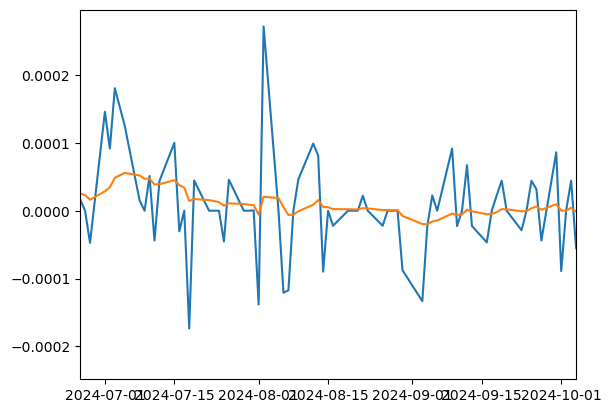

In [30]:
plt.plot(ab_params_df['AAPL_a'])
plt.plot(ab_params_df['AAPL_a'].ewm(span=20).mean())

In [32]:
ticker_hist_pl.columns

/var/folders/t5/hglcpfcd3px36gr5wgd_4mtm0000gn/T/ipykernel_97226/3582729767.py:1: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  ticker_hist_pl.columns


['Open',
 'Close',
 'high',
 'low',
 'volume',
 'Datetime',
 'transactions',
 'ticker',
 'Date',
 'Time',
 'logOpen',
 'logClose',
 'logReturns']

In [45]:
ticker_hist_pl.filter(pl.col('ticker')=='AAPL').select('logReturns').mean().collect()

logReturns
f64
5.1174e-7


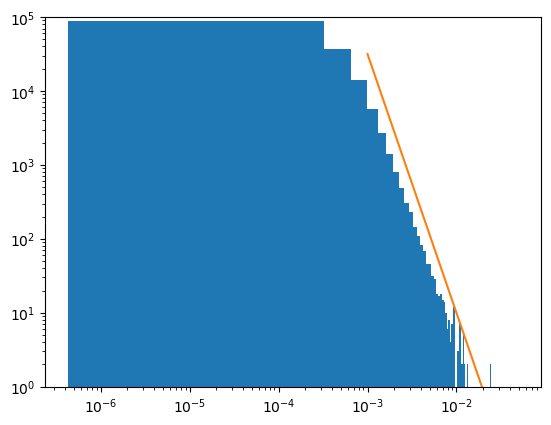

In [76]:
plt.hist(
    np.abs(ticker_hist_pl.filter(pl.col('ticker')=='AAPL').filter(pl.col('logReturns')>0).select('logReturns').collect()),
    bins=100
)



plt.plot(np.arange(0.001,0.05,0.0001), 0.000001/np.arange(0.001,0.05,0.0001)**3.5)

plt.yscale('log')
plt.ylim((10**0,10**5))

plt.xscale('log')
plt.show()

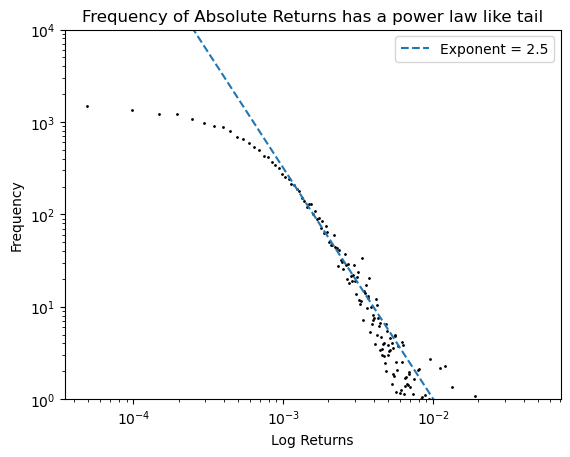

In [244]:
counts, bin_edges = np.histogram(
    np.abs(ticker_hist_pl.filter(pl.col('ticker')=='AAPL').select('logReturns').collect()),
    weights = ticker_hist_pl.filter(pl.col('ticker')=='AAPL').select('volume').collect(),
    bins = 1000,
    density = True
)

plt.scatter(bin_edges[:-1], counts, s = 1, color = 'black')

plt.plot(np.arange(0.0001,0.05,0.00001), 0.00001/np.arange(0.0001,0.05,0.00001)**2.5, ls = '--', label = 'Exponent = 2.5')
plt.ylabel('Frequency')
plt.xlabel('Log Returns')

plt.title('Frequency of Absolute Returns has a power law like tail')
plt.legend(loc = 'best')
plt.yscale('log')
plt.ylim((10**0,10**4))

plt.xscale('log')

plt.savefig('power_law_tails.pdf', bbox_inches = 'tight')

In [80]:
max(dates)

datetime.date(2024, 10, 14)

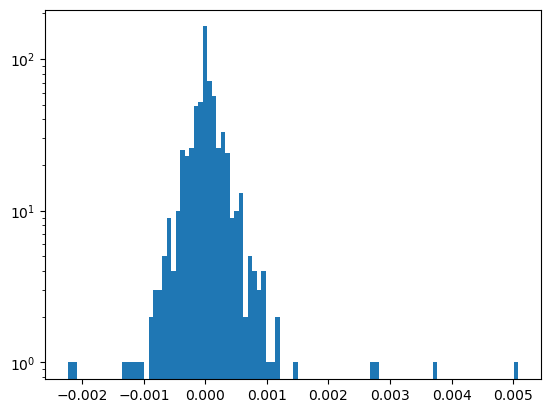

In [90]:
plt.hist(
    (
        ticker_hist_pl
        .filter(pl.col('ticker')=='AAPL')
        .filter(pl.col('Date')==max(dates))
        .select('logReturns')
        .collect()
    ),
    bins=100
)
plt.yscale('log')
plt.show()

In [101]:
pacfs = np.zeros((41, 504))
confints = np.zeros((41, 2, 504))

for index, col in enumerate(a_params_df.columns):
    pacfs[:,index], confints[:,:,index] = statsmodels.tsa.stattools.pacf(a_params_df[col], nlags = 40, alpha=0.05)

In [113]:
from sklearn.feature_selection import mutual_info_regression

mutual_info_regression(ab_params_df.shift(-1)['AAPL_a'].iloc[:-1].values.reshape(-1,1), b_params_df['AAPL_b'].iloc[:-1].values.reshape(-1,1))

/Users/hiroku007/miniforge3/envs/algo_trading/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([0.10109012])

In [105]:
scipy.stats.spearmanr(ab_params_df['MMM_b'].iloc[:-1], ab_params_df.shift(-1)['MMM_b'].iloc[:-1])

SignificanceResult(statistic=np.float64(0.4311231324925299), pvalue=np.float64(4.763264879233703e-24))

In [114]:
test_data = ab_params_df[['MMM_a', 'MMM_b']]

In [99]:
ab_params_valuesab_params_df.values

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         9.38473563e-02,  8.70826289e-02,  1.30321505e-01],
       [ 8.60692734e-05,  0.00000000e+00,  0.00000000e+00, ...,
         1.13312740e-01,  1.21236263e-01,  1.86752971e-01],
       [ 4.40100720e-05,  9.71015197e-05,  0.00000000e+00, ...,
         7.37202271e-02,  1.00827025e-01,  1.62581109e-01],
       ...,
       [-3.74665143e-05,  0.00000000e+00, -8.63744332e-05, ...,
         4.81930390e-02,  6.30829599e-02,  1.50132111e-01],
       [-2.46634624e-05, -3.10950108e-05,  0.00000000e+00, ...,
         4.00261406e-02,  6.66040864e-02,  8.67827423e-02],
       [-7.36512613e-05,  0.00000000e+00,  0.00000000e+00, ...,
         5.71303388e-02,  5.75841734e-02,  7.16251181e-02]])

In [126]:
one_shifted = a_params_df.shift(-1)
one_shifted.columns = [f'{col_name}_shift1' for col_name in a_params_df.columns]
one_shifted = pd.DataFrame(one_shifted.values.flatten())

two_shifted = a_params_df.shift(-2)
two_shifted.columns = [f'{col_name}_shift2' for col_name in a_params_df.columns]
two_shifted = pd.DataFrame(two_shifted.values.flatten())

three_shifted = a_params_df.shift(-3)
three_shifted.columns = [f'{col_name}_shift3' for col_name in a_params_df.columns]
three_shifted = pd.DataFrame(three_shifted.values.flatten())

four_shifted = a_params_df.shift(-4)
four_shifted.columns = [f'{col_name}_shift4' for col_name in a_params_df.columns]
four_shifted = pd.DataFrame(four_shifted.values.flatten())

five_shifted = a_params_df.shift(-5)
five_shifted.columns = [f'{col_name}_shift5' for col_name in a_params_df.columns]
five_shifted = pd.DataFrame(five_shifted.values.flatten())



In [124]:
a_params_df

,MMM_a,AOS_a,ABT_a,ABBV_a,ACN_a,ADBE_a,AMD_a,AES_a,AFL_a,A_a,...,WMB_a,WTW_a,WYNN_a,XEL_a,XYL_a,YUM_a,ZBRA_a,ZBH_a,ZTS_a,VIXY_a
2022-10-17,0.000000,0.000000,0.000000,0.000038,0.000095,0.000034,0.000133,0.000000,0.000000,0.000000,...,0.000000,-0.000096,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
2022-10-18,0.000086,0.000000,0.000000,0.000014,0.000000,0.000000,-0.000002,0.000000,0.000000,0.000000,...,0.000164,0.000000,-0.000174,0.000000,0.000080,0.000045,0.000000,0.000000,0.000000,0.0
2022-10-19,0.000044,0.000097,0.000000,0.000035,0.000000,0.000053,-0.000086,-0.000205,0.000166,0.000023,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
2022-10-20,0.000000,0.000000,0.000000,0.000070,0.000000,0.000033,0.000054,0.000000,-0.000085,0.000077,...,0.000000,-0.000121,0.000177,0.000000,0.000000,0.000000,-0.000087,0.000055,0.000000,0.0
2022-10-21,0.000087,0.000100,-0.000105,0.000103,-0.000075,0.000033,0.000122,0.000000,0.000000,-0.000077,...,0.000000,0.000071,0.000000,0.000000,0.000054,0.000000,0.000000,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-08,-0.000075,0.000000,0.000000,0.000000,-0.000014,-0.000040,0.000068,0.000000,0.000000,0.000000,...,0.000000,0.000000,-0.000097,0.000000,0.000000,-0.000055,0.000000,-0.000098,0.000000,0.0
2024-10-09,0.000037,0.000000,0.000000,0.000000,0.000014,-0.000030,-0.000120,0.000000,0.000000,0.000000,...,0.000000,0.000101,0.000096,-0.000080,0.000000,-0.000037,0.000000,0.000000,0.000026,0.0
2024-10-10,-0.000037,0.000000,-0.000086,0.000000,0.000000,0.000020,-0.000107,0.000000,0.000000,-0.000035,...,0.000000,0.000000,-0.000096,-0.000080,-0.000015,-0.000075,0.000000,0.000000,0.000000,0.0
2024-10-11,-0.000025,-0.000031,0.000000,-0.000026,0.000055,-0.000100,0.000119,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000037,0.000000,0.000048,0.000000,0.0


In [132]:
one_shifted

,0
0,0.000086
1,0.000000
2,0.000000
3,0.000014
4,0.000000
...,...
252499,NaN
252500,NaN
252501,NaN
252502,NaN


In [121]:
collapsed_df = pd.DataFrame(a_params_df.values.flatten())


In [137]:
a_params_with_shifts_collapsed = pd.concat([collapsed_df, one_shifted, two_shifted, three_shifted, four_shifted, five_shifted], axis=1)


In [139]:
a_params_with_shifts_collapsed.columns = ['0 shift', '1 shift', '2 shift', '3 shift', '4 shift', '5 shift']

In [140]:
a_params_with_shifts_collapsed

,0 shift,1 shift,2 shift,3 shift,4 shift,5 shift
0,0.000000,0.000086,0.000044,0.00000,0.000087,0.000000
1,0.000000,0.000000,0.000097,0.00000,0.000100,0.000000
2,0.000000,0.000000,0.000000,0.00000,-0.000105,0.000041
3,0.000038,0.000014,0.000035,0.00007,0.000103,0.000117
4,0.000095,0.000000,0.000000,0.00000,-0.000075,0.000000
...,...,...,...,...,...,...
252499,-0.000111,NaN,NaN,NaN,NaN,NaN
252500,0.000000,NaN,NaN,NaN,NaN,NaN
252501,0.000000,NaN,NaN,NaN,NaN,NaN
252502,-0.000026,NaN,NaN,NaN,NaN,NaN


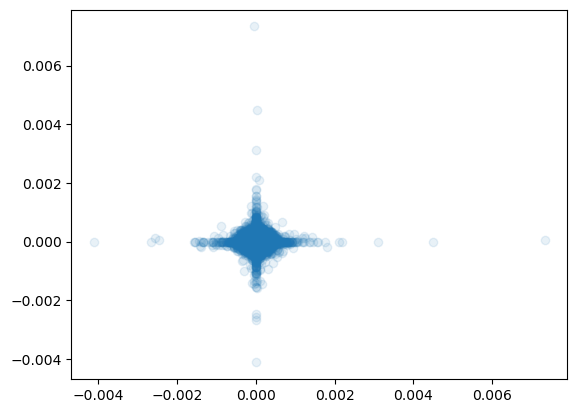

In [169]:
plt.scatter(a_params_with_shifts_collapsed['0 shift'], a_params_with_shifts_collapsed['4 shift'], alpha=0.1)

In [170]:
scipy.stats.spearmanr(
    a_params_with_shifts_collapsed.dropna()['0 shift'], 
    a_params_with_shifts_collapsed.dropna()['1 shift']
)

SignificanceResult(statistic=np.float64(0.0576650053068159), pvalue=np.float64(9.340652240062415e-180))

In [150]:
import xgboost

xgb_regressor = xgboost.XGBRegressor()
a_params_with_shifts_collapsed.dropna()

,0 shift,1 shift,2 shift,3 shift,4 shift,5 shift
0,0.000000,0.000086,0.000044,0.000000,0.000087,0.000000
1,0.000000,0.000000,0.000097,0.000000,0.000100,0.000000
2,0.000000,0.000000,0.000000,0.000000,-0.000105,0.000041
3,0.000038,0.000014,0.000035,0.000070,0.000103,0.000117
4,0.000095,0.000000,0.000000,0.000000,-0.000075,0.000000
...,...,...,...,...,...,...
249979,0.000000,-0.000055,-0.000037,-0.000075,0.000037,-0.000111
249980,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
249981,-0.000049,-0.000098,0.000000,0.000000,0.000048,0.000000
249982,0.000000,0.000000,0.000026,0.000000,0.000000,-0.000026


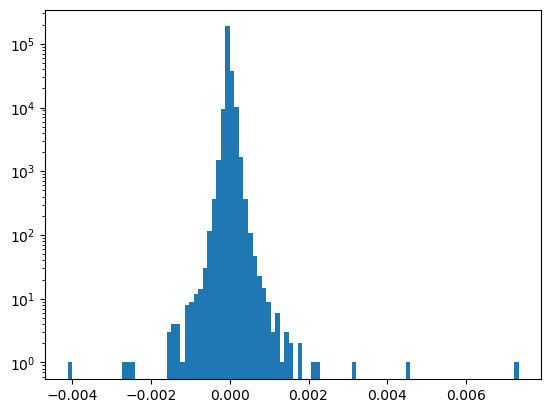

In [149]:
plt.hist(a_params_with_shifts_collapsed['0 shift'], bins = 100)
plt.yscale('log')

In [135]:
collapsed_df.join(one_shifted).join(two_shifted).join(three_shifted).join(four_shifted).join(five_shifted)

ValueError: columns overlap but no suffix specified: RangeIndex(start=0, stop=1, step=1)

In [119]:
train_data

,MMM_a,MMM_b
2022-10-10,0.000000,0.090958
2022-10-11,0.000059,0.088458
2022-10-12,0.000000,0.090556
2022-10-13,0.000087,0.153892
2022-10-14,0.000044,0.115216
...,...,...
2024-05-07,-0.000052,0.065985
2024-05-08,0.000104,0.050694
2024-05-09,0.000104,0.038244
2024-05-10,0.000000,0.078609


In [126]:
targets

,MMM_a
2022-10-10,0.000059
2022-10-11,0.000000
2022-10-12,0.000087
2022-10-13,0.000044
2022-10-14,0.000000
...,...
2024-05-07,0.000104
2024-05-08,0.000104
2024-05-09,0.000000
2024-05-10,-0.000025


In [151]:
from sklearn.linear_model import LinearRegression

test_data = ab_params_df.iloc[400:,:][['AAPL_a', 'AAPL_b']]
train_data = ab_params_df.iloc[:400,:][['AAPL_a', 'AAPL_b']]

targets = train_data.shift(-1).iloc[:-1, :].values
features = train_data.iloc[:-1, :].values

test_targets = test_data.shift(-1).iloc[:-1, :].values
test_features = test_data.iloc[:-1, :].values

linear_regressor = LinearRegression()
linear_regressor.fit(features, targets[:,0])
print(linear_regressor.score(features, targets[:,0]))
print(linear_regressor.score(test_features, test_targets[:,0]))

0.003974186763087251
-0.0013481416721279338


In [152]:
linear_regressor.fit(features, targets[:,1])
print(linear_regressor.score(features, targets[:,1]))
print(linear_regressor.score(test_features, test_targets[:,1]))

0.4881725582859101
0.38727855252636023


In [153]:
import xgboost
xgb_regress = xgboost.XGBRegressor()

xgb_regress.fit(features, targets[:,0])
print(xgb_regress.score(test_features, test_targets[:,0]))

xgb_regress.fit(features, targets[:,1])
print(xgb_regress.score(test_features, test_targets[:,1]))



-0.03853359888716934
0.21399277989398136


In [154]:
for i in range(1,6):
    for col in ['AAPL_a', 'AAPL_b']:
        train_data[col + '_shift_{}'.format(i)] = train_data[col].shift(i)
        test_data[col + '_shift_{}'.format(i)] = test_data[col].shift(i)
        

In [166]:
train_data[list(train_data.columns)[10]]

2022-10-10         NaN
2022-10-11         NaN
2022-10-12         NaN
2022-10-13         NaN
2022-10-14         NaN
                ...   
2024-05-07   -0.000087
2024-05-08   -0.000106
2024-05-09    0.000058
2024-05-10    0.000022
2024-05-13    0.000000
Name: AAPL_a_shift_5, Length: 400, dtype: float64

In [170]:
linear_regressor.fit(train_data[train_data.columns[:10]].iloc[5:,:], train_data[list(train_data.columns)[10]].iloc[5:])
print(
    linear_regressor.score(train_data[train_data.columns[:10]].iloc[5:,:], train_data[list(train_data.columns)[10]].iloc[5:])
)
print(
    linear_regressor.score(test_data[train_data.columns[:10]].iloc[5:,:], test_data[list(train_data.columns)[10]].iloc[5:])
)


0.028096481165790443
-0.10636329722769977


In [171]:
linear_regressor.fit(train_data[train_data.columns[:10]].iloc[5:,:], train_data[list(train_data.columns)[11]].iloc[5:])
print(
    linear_regressor.score(train_data[train_data.columns[:10]].iloc[5:,:], train_data[list(train_data.columns)[11]].iloc[5:])
)
print(
    linear_regressor.score(test_data[train_data.columns[:10]].iloc[5:,:], test_data[list(train_data.columns)[11]].iloc[5:])
)


0.593751734779046
0.33815724834518557


In [172]:
xgb_regress = xgboost.XGBRegressor()

xgb_regress.fit(train_data[train_data.columns[:10]].iloc[5:,:], train_data[list(train_data.columns)[10]].iloc[5:])
print(xgb_regress.score(train_data[train_data.columns[:10]].iloc[5:,:], train_data[list(train_data.columns)[10]].iloc[5:]))
print(xgb_regress.score(test_data[train_data.columns[:10]].iloc[5:,:], test_data[list(train_data.columns)[10]].iloc[5:]))


xgb_regress.fit(train_data[train_data.columns[:10]].iloc[5:,:], train_data[list(train_data.columns)[11]].iloc[5:])
print(xgb_regress.score(train_data[train_data.columns[:10]].iloc[5:,:], train_data[list(train_data.columns)[11]].iloc[5:]))
print(xgb_regress.score(test_data[train_data.columns[:10]].iloc[5:,:], test_data[list(train_data.columns)[11]].iloc[5:]))


0.0
-0.04502135130559459
0.9988548607568912
0.3815758770727322


In [216]:
np.real(np.linalg.eig(ab_params_df.dropna(axis=1).corr()).eigenvalues)


array([ 1.93682789e+02,  4.03652468e+01,  2.26317728e+01,  1.44506108e+01,
        1.40678551e+01,  1.23138731e+01,  1.00372034e+01,  9.10485010e+00,
        7.10712334e+00,  6.65229558e+00,  6.41351301e+00,  6.10580288e+00,
        5.99348467e+00,  5.68836626e+00,  5.60310247e+00,  5.39193488e+00,
        5.16780608e+00,  5.11242368e+00,  5.04185191e+00,  4.96904003e+00,
        4.89797472e+00,  4.80216926e+00,  4.70123920e+00,  4.57285705e+00,
        4.54191722e+00,  4.47247293e+00,  4.33484789e+00,  4.30416956e+00,
        4.24763489e+00,  4.22954950e+00,  4.14535658e+00,  4.10619298e+00,
        4.06005882e+00,  4.01628106e+00,  3.91218848e+00,  3.91647414e+00,
        3.82837057e+00,  3.79118952e+00,  3.76085902e+00,  3.72885423e+00,
        3.70694009e+00,  3.68662407e+00,  3.66670695e+00,  3.63531969e+00,
        3.58017031e+00,  3.51768371e+00,  3.54120487e+00,  3.47346852e+00,
        3.45714057e+00,  3.45349190e+00,  3.40172756e+00,  3.38371104e+00,
        3.34908369e+00,  

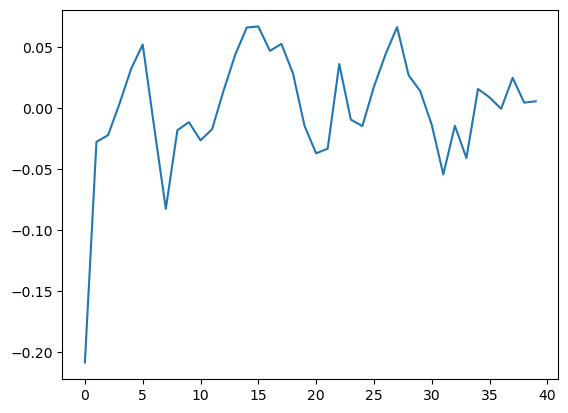

In [222]:
plt.plot(sm.tsa.stattools.ccf(ab_params_df['ABNB_b'], ab_params_df['ABNB_a'])[:40])

[[ 1.         -0.10207074]
 [-0.10207074  1.        ]]
[[ 1.        -0.3291722]
 [-0.3291722  1.       ]]
[[ 1.         -0.06348189]
 [-0.06348189  1.        ]]
[[ 1.         -0.75390103]
 [-0.75390103  1.        ]]
[[1.         0.25566119]
 [0.25566119 1.        ]]
[[ 1.         -0.25963227]
 [-0.25963227  1.        ]]
[[ 1.         -0.53558368]
 [-0.53558368  1.        ]]


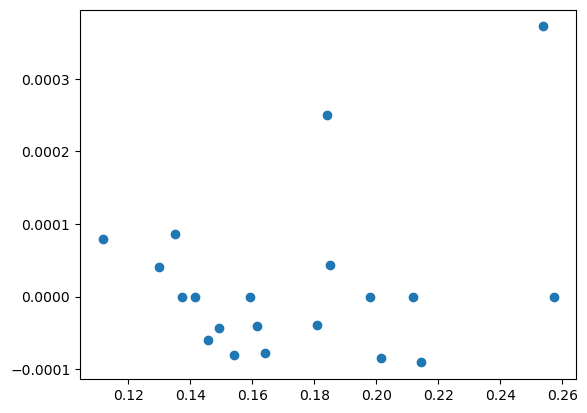

In [235]:
print(np.corrcoef(ab_params_df['ABNB_b'].iloc[60:80], ab_params_df['ABNB_a'][60:80]))
print(np.corrcoef(ab_params_df['ABNB_b'].iloc[40:60], ab_params_df['ABNB_a'][40:60]))
print(np.corrcoef(ab_params_df['ABNB_b'].iloc[20:40], ab_params_df['ABNB_a'][20:40]))
print(np.corrcoef(ab_params_df['ABNB_b'].iloc[:20], ab_params_df['ABNB_a'][:20]))
print(np.corrcoef(ab_params_df['ABNB_b'].iloc[80:100], ab_params_df['ABNB_a'][80:100]))
print(np.corrcoef(ab_params_df['ABNB_b'].iloc[100:120], ab_params_df['ABNB_a'][100:120]))
print(np.corrcoef(ab_params_df['ABNB_b'].iloc[120:140], ab_params_df['ABNB_a'][120:140]))

plt.scatter(ab_params_df['ABNB_b'].iloc[80:100], ab_params_df['ABNB_a'][80:100])


In [243]:
print(np.corrcoef(ab_params_df.shift(-1)['ABNB_a'].iloc[0:20], ab_params_df['ABNB_a'][0:20]))
print(np.corrcoef(ab_params_df.shift(-1)['ABNB_a'].iloc[20:40], ab_params_df['ABNB_a'][20:40]))
print(np.corrcoef(ab_params_df.shift(-1)['ABNB_a'].iloc[40:60], ab_params_df['ABNB_a'][40:60]))
print(np.corrcoef(ab_params_df.shift(-1)['ABNB_a'].iloc[60:80], ab_params_df['ABNB_a'][60:80]))
print(np.corrcoef(ab_params_df.shift(-1)['ABNB_a'].iloc[1:21], ab_params_df['ABNB_a'][1:21]))
print(np.corrcoef(ab_params_df.shift(-1)['ABNB_a'].iloc[2:22], ab_params_df['ABNB_a'][2:22]))


[[1.         0.00484899]
 [0.00484899 1.        ]]
[[ 1.         -0.26792501]
 [-0.26792501  1.        ]]
[[ 1.        -0.3884713]
 [-0.3884713  1.       ]]
[[ 1.         -0.24092313]
 [-0.24092313  1.        ]]
[[1.         0.04883475]
 [0.04883475 1.        ]]
[[1.         0.03607493]
 [0.03607493 1.        ]]


24/10/07 21:52:25 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:123)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:688)
	at org.apache.spark.storage.BlockManagerMasterE

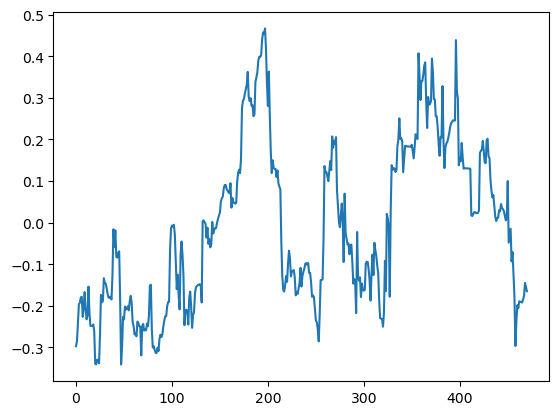

In [266]:
autocorrs = []
for i in range(480):
    autocorrs.append(
        np.corrcoef(
            ab_params_df.shift(-1)['MMM_a'].iloc[i:i+30], 
            ab_params_df['MMM_a'].iloc[i:i+30], 
        )[0,1]
    )
plt.plot(autocorrs)

In [293]:
test = ab_params_df['ABNB_a'].sample(frac=1).reset_index(drop=True)

In [291]:
test

0      0.000101
1      0.000000
2     -0.000031
3      0.000071
4      0.000000
         ...   
496    0.000033
497    0.000140
498   -0.000095
499    0.000000
500    0.000000
Name: ABNB_a, Length: 501, dtype: float64

In [292]:
ab_params_df['ABNB_a']

2022-10-10   -0.000134
2022-10-11   -0.000187
2022-10-12   -0.000023
2022-10-13    0.000036
2022-10-14   -0.000183
                ...   
2024-10-01    0.000080
2024-10-02    0.000040
2024-10-03    0.000000
2024-10-04    0.000076
2024-10-07    0.000211
Name: ABNB_a, Length: 501, dtype: float64

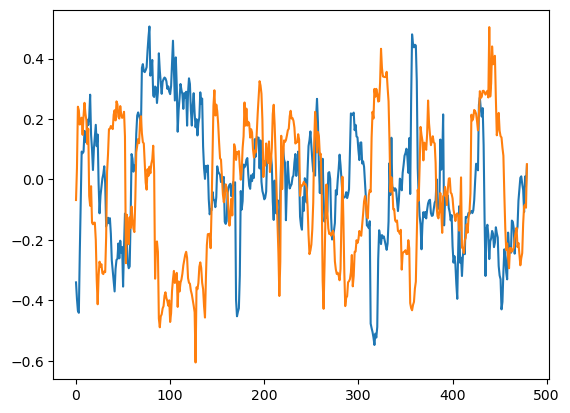

In [314]:
autocorrs = []
for i in range(480):
    autocorrs.append(
        np.corrcoef(
            ab_params_df.shift(-1)['NVDA_a'].iloc[i:i+20], 
            ab_params_df['NVDA_a'].iloc[i:i+20], 
        )[0,1]
    )

plt.plot(autocorrs)
test = ab_params_df['NVDA_a'].sample(frac=1).reset_index(drop=True)

noise_autocorrs = []
for i in range(480):
    noise_autocorrs.append(
        np.corrcoef(
            test.shift(-1).iloc[i:i+20], 
            test.iloc[i:i+20], 
        )[0,1]
    )


plt.plot(noise_autocorrs)

In [295]:
import scipy.fft

In [315]:
ffted_signal_noise = []

for r in range(100):

    test = ab_params_df['NVDA_a'].sample(frac=1).reset_index(drop=True)
    noise_autocorrs = []
    for i in range(480):
        noise_autocorrs.append(
            np.corrcoef(
                test.shift(-1).iloc[i:i+20], 
                test.iloc[i:i+20], 
            )[0,1]
        )    
    ffted_signal_noise.append(scipy.fft.rfft(noise_autocorrs))
ffted_signal_real = scipy.fft.rfft(autocorrs)
fft_freq = scipy.fft.rfftfreq(len(autocorrs), 1)

(0.0, 0.1)

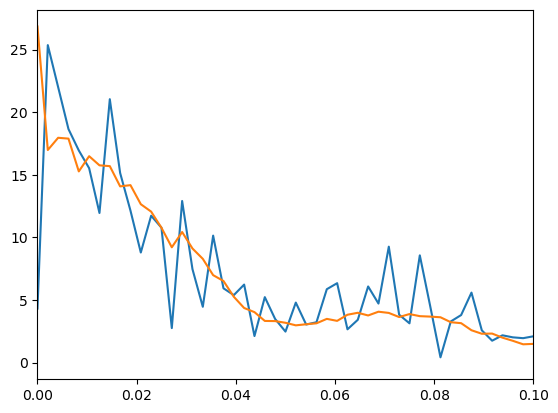

In [316]:
plt.plot(fft_freq, np.abs(ffted_signal_real))
plt.plot(fft_freq, np.mean(np.abs(np.asarray(ffted_signal_noise)), axis=0))
plt.xlim(0,0.1)


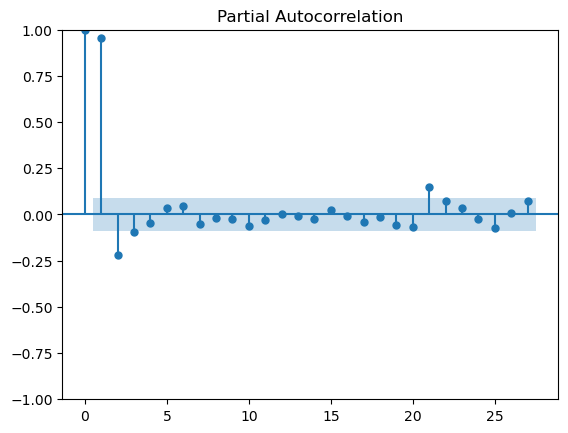

In [287]:
statsmodels.graphics.tsaplots.plot_pacf(np.asarray(autocorrs))
plt.show()

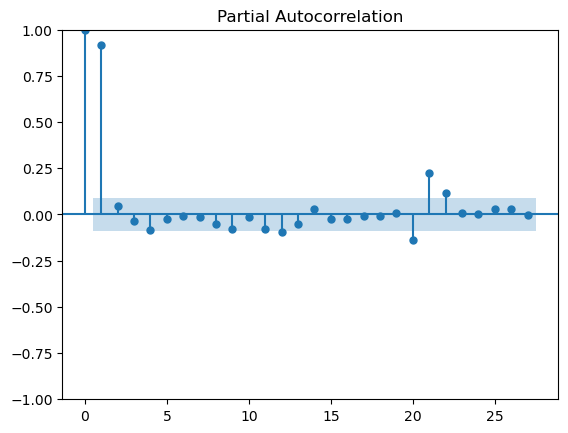

In [289]:
statsmodels.graphics.tsaplots.plot_pacf(np.asarray(noise_autocorrs))
plt.show()

p(log returns)

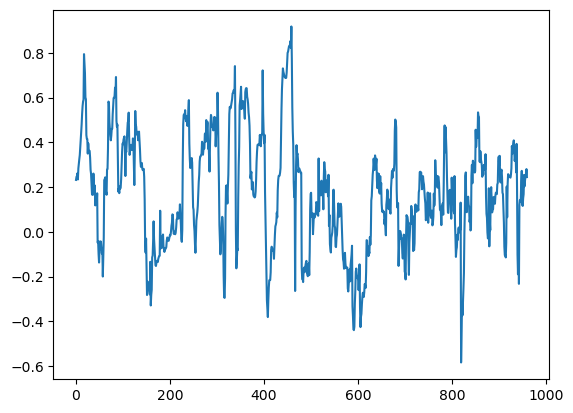

In [256]:
for i in range(480):
    autocorrs.append(
        np.corrcoef(
            ab_params_df.shift(-1)['ABNB_a'].iloc[i:i+20], 
            ab_params_df['ABNB_b'].iloc[i:i+20], 
        )[0,1]
    )
plt.plot(autocorrs)
autocorrs = []

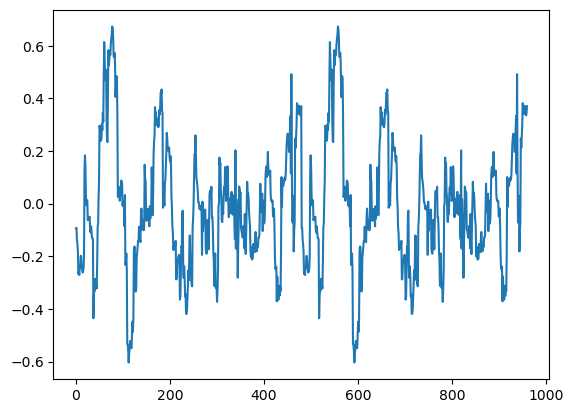

In [258]:
for i in range(480):
    autocorrs.append(
        np.corrcoef(
            ab_params_df.shift(-1)['ABNB_b'].iloc[i:i+20], 
            ab_params_df['ABNB_a'].iloc[i:i+20], 
        )[0,1]
    )
plt.plot(autocorrs)

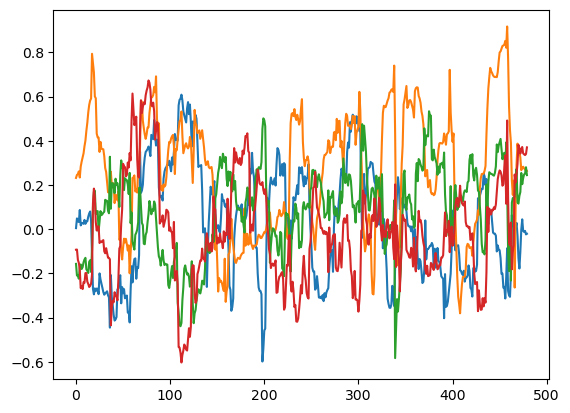

In [252]:
autocorrs = []
for i in range(480):
    autocorrs.append(
        np.corrcoef(
            ab_params_df.shift(-1)['ABNB_a'].iloc[i:i+20], 
            ab_params_df['ABNB_a'].iloc[i:i+20], 
        )[0,1]
    )
plt.plot(autocorrs)
autocorrs = []
for i in range(480):
    autocorrs.append(
        np.corrcoef(
            ab_params_df.shift(-1)['ABNB_b'].iloc[i:i+20], 
            ab_params_df['ABNB_b'].iloc[i:i+20], 
        )[0,1]
    )
plt.plot(autocorrs)
autocorrs = []
for i in range(480):
    autocorrs.append(
        np.corrcoef(
            ab_params_df.shift(-1)['ABNB_a'].iloc[i:i+20], 
            ab_params_df['ABNB_b'].iloc[i:i+20], 
        )[0,1]
    )
plt.plot(autocorrs)
autocorrs = []
for i in range(480):
    autocorrs.append(
        np.corrcoef(
            ab_params_df.shift(-1)['ABNB_b'].iloc[i:i+20], 
            ab_params_df['ABNB_a'].iloc[i:i+20], 
        )[0,1]
    )
plt.plot(autocorrs)

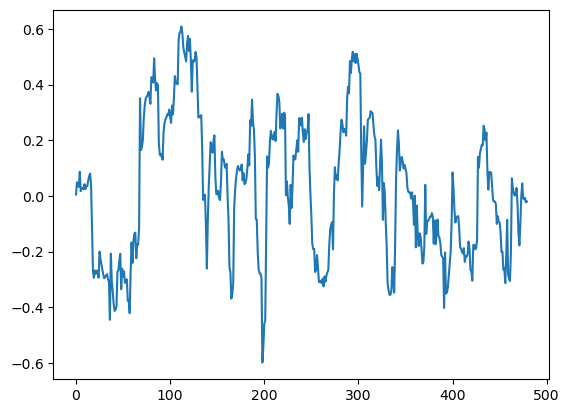

In [247]:
plt.plot(autocorrs)

In [249]:
statsmodels.tsa.stattools.acf(autocorrs)

array([1.        , 0.94819185, 0.89446781, 0.84106924, 0.78152848,
       0.72438082, 0.66708659, 0.61089234, 0.55614239, 0.51367686,
       0.47142741, 0.4323579 , 0.40334377, 0.37332023, 0.34503179,
       0.31672802, 0.28740427, 0.25981501, 0.22918901, 0.19787004,
       0.15775337, 0.15278071, 0.15357247, 0.1511697 , 0.15888764,
       0.16732954, 0.17295005])

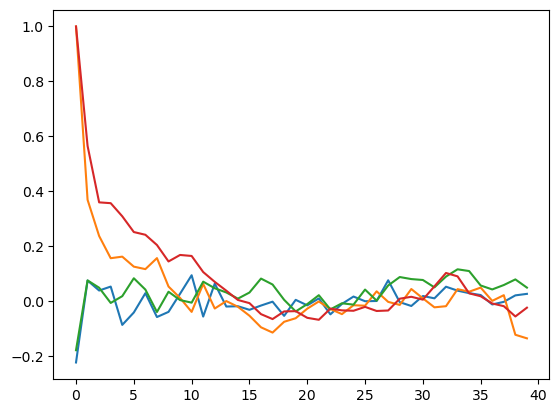

In [199]:
import statsmodels.api as sm

ab_corrs = np.

for ticker in all_tickers:

#plt.plot(sm.tsa.stattools.ccf(ab_params_df['NVDA_a'], ab_params_df['NVDA_b'])[:40])
#plt.plot(sm.tsa.stattools.ccf(ab_params_df['NVDA_b'], ab_params_df['NVDA_b'])[:40])

#plt.plot(sm.tsa.stattools.ccf(ab_params_df['AAPL_a'], ab_params_df['AAPL_b'])[:40])
#plt.plot(sm.tsa.stattools.ccf(ab_params_df['AAPL_b'], ab_params_df['AAPL_b'])[:40])

#plt.plot(sm.tsa.stattools.ccf(ab_params_df['GOOG_a'], ab_params_df['GOOG_b'])[:40])
#plt.plot(sm.tsa.stattools.ccf(ab_params_df['GOOG_b'], ab_params_df['GOOG_b'])[:40])

#plt.plot(sm.tsa.stattools.ccf(ab_params_df['MSFT_a'], ab_params_df['MSFT_b'])[:40])
#plt.plot(sm.tsa.stattools.ccf(ab_params_df['MSFT_b'], ab_params_df['MSFT_b'])[:40])

plt.plot(sm.tsa.stattools.ccf(ab_params_df['MMM_a'], ab_params_df['MMM_b'])[:40])
plt.plot(sm.tsa.stattools.ccf(ab_params_df['MMM_b'], ab_params_df['MMM_b'])[:40])

plt.plot(sm.tsa.stattools.ccf(ab_params_df['CAT_a'], ab_params_df['CAT_b'])[:40])
plt.plot(sm.tsa.stattools.ccf(ab_params_df['CAT_b'], ab_params_df['CAT_b'])[:40])



plt.plot(sm.tsa.stattools.ccf(ab_params_df['CAT_a'], ab_params_df['CAT_b'])[:40])
plt.plot(sm.tsa.stattools.ccf(ab_params_df['CAT_b'], ab_params_df['CAT_b'])[:40])





In [176]:
ab_params_df.shift(-1)

,MMM_a,AOS_a,ABT_a,ABBV_a,ACN_a,ADBE_a,AMD_a,AES_a,AFL_a,A_a,...,WMB_b,WTW_b,WYNN_b,XEL_b,XYL_b,YUM_b,ZBRA_b,ZBH_b,ZTS_b,VIXY_b
2022-10-10,0.000059,0.000000,0.000000,0.000070,-0.000059,0.000105,0.000086,0.000000,0.000000,0.000080,...,0.139534,0.063241,0.334983,0.135756,0.087372,0.089226,0.074856,0.096282,0.109590,0.217540
2022-10-11,0.000000,0.000000,0.000000,-0.000071,-0.000139,-0.000138,0.000000,0.000000,-0.000171,-0.000080,...,0.125558,0.069831,0.214554,0.104564,0.090688,0.080618,0.087351,0.116119,0.099811,0.171891
2022-10-12,0.000087,0.000205,0.000049,0.000070,-0.000146,0.000170,0.000238,0.000000,0.000000,0.000234,...,0.164983,0.144484,0.328541,0.145887,0.154414,0.142362,0.156009,0.139829,0.151535,0.216496
2022-10-13,0.000044,0.000000,-0.000049,-0.000035,0.000000,0.000000,-0.000332,0.000000,0.000000,0.000000,...,0.137924,0.094613,0.240982,0.099091,0.125098,0.109487,0.089725,0.093615,0.117183,0.229934
2022-10-14,0.000000,0.000000,0.000000,0.000069,0.000099,0.000034,0.000066,0.000000,0.000000,0.000038,...,0.099854,0.059524,0.172041,0.086761,0.096625,0.070995,0.056162,0.090284,0.076016,0.127369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-01,-0.000074,0.000000,0.000000,-0.000025,0.000007,-0.000017,0.000062,0.000000,0.000000,0.000034,...,0.062062,0.023542,0.119813,0.043621,0.054871,0.047474,0.024909,0.047067,0.063356,0.269723
2024-10-02,0.000000,0.000000,-0.000044,0.000025,0.000055,0.000020,0.000043,-0.000252,0.000000,0.000000,...,0.082079,0.030687,0.119719,0.052349,0.048709,0.048304,0.031111,0.052822,0.065216,0.340280
2024-10-03,0.000074,-0.000114,0.000000,0.000000,-0.000055,0.000000,0.000120,0.000000,0.000000,-0.000104,...,0.089961,0.032510,0.106525,0.054104,0.054024,0.050900,0.020730,0.080003,0.087350,0.195924
2024-10-04,-0.000041,0.000000,0.000353,0.000256,0.000042,-0.000162,0.000002,-0.000265,0.000000,0.000384,...,0.043615,0.034100,0.083748,0.037803,0.022106,0.031615,0.021027,0.033880,0.033371,0.078273


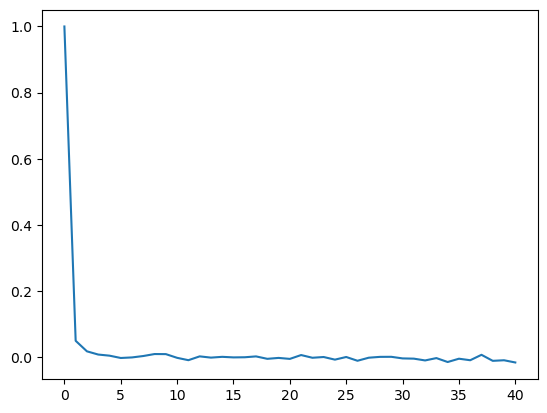

In [105]:
plt.plot(np.nanmean(pacfs, axis=1))

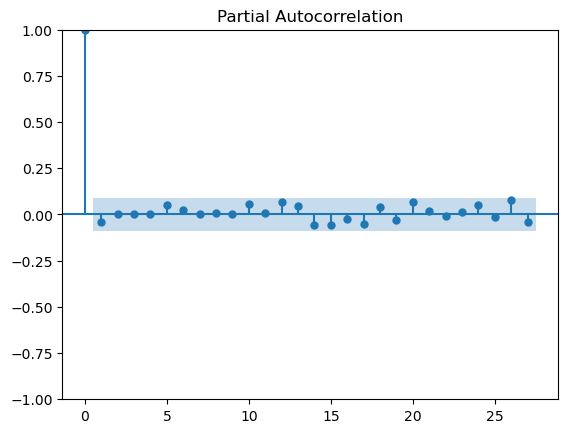

In [96]:
import statsmodels
import statsmodels.tsa.stattools
import statsmodels.graphics.tsaplots

pacfs, confints = statsmodels.tsa.stattools.pacf(ab_params_df['A_a'], nlags = 40, alpha=0.05)
statsmodels.graphics.tsaplots.plot_pacf(ab_params_df['A_a'])
plt.show()

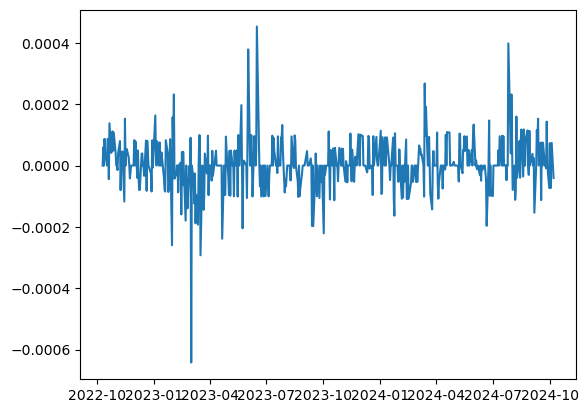

In [59]:
plt.plot(a_params_df.iloc[:,0])

In [9]:
ticker_hist_date = ticker_hist.filter(pyspark.sql.functions.col("Ticker")=="MSFT").filter(pyspark.sql.functions.col("Date")==datetime.date(2024,9,20)).toPandas()

24/10/07 13:34:56 WARN TaskSetManager: Stage 5 contains a task of very large size (2276 KiB). The maximum recommended task size is 1000 KiB.


In [12]:
results = ticker_hist.select('Date').distinct().collect()


24/10/07 13:55:34 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
24/10/07 13:55:34 WARN TaskSetManager: Stage 9 contains a task of very large size (1308 KiB). The maximum recommended task size is 1000 KiB.
24/10/07 13:57:38 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB


In [22]:
dates = [date[0] for date in results]
all_tickers = list(tickers['Symbol']) + ['VIXY']

In [26]:
ticker_hist = ticker_hist.repartition(2000)

In [28]:
a_params = {}
b_params = {}



for ticker in tqdm(all_tickers):
    a_params[ticker] = {}
    b_params[ticker] = {}
    
    # Filter the Polars DataFrame for the specific ticker
    ticker_hist = enormous_frame_time_filtered.filter(pl.col('ticker') == ticker)
    
    if ticker_hist.height > 0:  # Equivalent to len() in Pandas
        for date in dates:
            # Filter the DataFrame for the specific date
            ticker_hist_date = ticker_hist.filter(pl.col('Date') == date)
            ticker_hist_date = ticker_hist_date.to_pandas()
            
            if len(ticker_hist_date)>0:
                ticker_hist_date = ticker_hist_date.sort_values('logReturns').reset_index(drop = True)
                ticker_hist_date.loc[:, 'cumulative_volume'] = ticker_hist_date['volume'].cumsum()/ticker_hist_date['volume'].sum()
        
                a_param = ticker_hist_date[ticker_hist_date['cumulative_volume']>=0.5]['logReturns'].iloc[0]
                mae = np.sum(abs(a_param - ticker_hist_date['logReturns'])*ticker_hist_date['cumulative_volume'])
                bessel_corrected_mae = mae * len(ticker_hist_date)/(len(ticker_hist_date)-1)
                a_params[ticker][date] = a_param
                b_params[ticker][date] = bessel_corrected_mae

  0%|                                                   | 0/501 [00:00<?, ?it/s]24/10/07 14:17:01 WARN TaskSetManager: Stage 583 contains a task of very large size (2276 KiB). The maximum recommended task size is 1000 KiB.
                                                                                
  0%|                                           | 1/501 [00:02<18:52,  2.27s/it]24/10/07 14:17:03 WARN TaskSetManager: Stage 586 contains a task of very large size (2276 KiB). The maximum recommended task size is 1000 KiB.
                                                                                
  0%|▏                                          | 2/501 [00:04<20:58,  2.52s/it]24/10/07 14:17:06 WARN TaskSetManager: Stage 589 contains a task of very large size (2276 KiB). The maximum recommended task size is 1000 KiB.
                                                                                
  1%|▎                                          | 3/501 [00:07<20:41,  2.49s/it]24/10/07

KeyboardInterrupt: 

In [10]:
a_params = {}
b_params = {}



for ticker in tqdm(all_tickers):
    a_params[ticker] = {}
    b_params[ticker] = {}
    
    # Filter the Polars DataFrame for the specific ticker
    ticker_hist = enormous_frame_time_filtered.filter(pl.col('ticker') == ticker)
    
    if ticker_hist.height > 0:  # Equivalent to len() in Pandas
        for date in dates:
            # Filter the DataFrame for the specific date
            ticker_hist_date = ticker_hist.filter(pl.col('Date') == date)
            ticker_hist_date = ticker_hist_date.to_pandas()
            
            if len(ticker_hist_date)>0:
                ticker_hist_date = ticker_hist_date.sort_values('logReturns').reset_index(drop = True)
                ticker_hist_date.loc[:, 'cumulative_volume'] = ticker_hist_date['volume'].cumsum()/ticker_hist_date['volume'].sum()
        
                a_param = ticker_hist_date[ticker_hist_date['cumulative_volume']>=0.5]['logReturns'].iloc[0]
                mae = np.sum(abs(a_param - ticker_hist_date['logReturns'])*ticker_hist_date['cumulative_volume'])
                bessel_corrected_mae = mae * len(ticker_hist_date)/(len(ticker_hist_date)-1)
                a_params[ticker][date] = a_param
                b_params[ticker][date] = bessel_corrected_mae

,Open,Close,high,low,volume,Datetime,transactions,ticker,Date,Time,logOpen,logClose,logReturns
0,438.1400,438.1400,438.1400,438.1400,1395.0,2024-09-20 04:02:00,71,MSFT,2024-09-20,04:02:00,6.082538,6.082538,0.000000
1,438.7400,438.7400,438.7400,438.7400,329.0,2024-09-20 04:08:00,21,MSFT,2024-09-20,04:08:00,6.083907,6.083907,0.000000
2,438.7000,438.7000,438.7000,438.7000,443.0,2024-09-20 04:09:00,15,MSFT,2024-09-20,04:09:00,6.083816,6.083816,0.000000
3,438.5000,438.5000,438.5000,438.5000,567.0,2024-09-20 04:10:00,28,MSFT,2024-09-20,04:10:00,6.083360,6.083360,0.000000
4,438.7900,438.7900,438.7900,438.7900,379.0,2024-09-20 04:13:00,18,MSFT,2024-09-20,04:13:00,6.084021,6.084021,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
550,435.9901,435.9901,435.9901,435.9901,105.0,2024-09-20 19:30:00,4,MSFT,2024-09-20,19:30:00,6.077620,6.077620,0.000000
551,436.0400,436.0500,436.0500,436.0400,388.0,2024-09-20 19:46:00,10,MSFT,2024-09-20,19:46:00,6.077734,6.077757,0.000023
552,436.0400,436.0400,436.0400,436.0400,1056.0,2024-09-20 19:54:00,6,MSFT,2024-09-20,19:54:00,6.077734,6.077734,0.000000
553,435.6320,435.6320,435.6320,435.6320,202.0,2024-09-20 19:57:00,5,MSFT,2024-09-20,19:57:00,6.076798,6.076798,0.000000


In [ ]:
missed_tickers = []

for ticker in tqdm(tickers['Symbol']):
    try: 
        price_performance = collections.defaultdict(list)
        aggs = []
        for agg in client.list_aggs(ticker=ticker, multiplier=1, timespan="minute", from_="2022-10-08", to="2024-10-07", limit=50000):
            price_performance['Open'].append(agg.open)
            price_performance['Close'].append(agg.close)
            price_performance['high'].append(agg.high)
            price_performance['low'].append(agg.low)
            price_performance['volume'].append(agg.volume)
            price_performance['Datetime'].append(datetime.datetime.fromtimestamp(agg.timestamp/1000))
            price_performance['transactions'].append(agg.transactions)
        if len(price_performance)>0:
            price_performance = spark.createDataFrame(pd.DataFrame(price_performance))
            price_performance = price_performance.withColumn("ticker", pyspark.sql.functions.lit(ticker))
        
            price_performance = price_performance.withColumn(
                "Date",
                pyspark.sql.functions.to_date(pyspark.sql.functions.col("Datetime"))
            )
            price_performance = price_performance.withColumn(
                "Time",
                pyspark.sql.functions.date_format(
                    pyspark.sql.functions.col("Datetime"),
                    "HH:mm:ss"
                )
            )
            price_performance = price_performance.withColumn(
                "logOpen",
                pyspark.sql.functions.log("Open")
            )
            price_performance = price_performance.withColumn(
                "logClose",
                pyspark.sql.functions.log("Close")
            )
            price_performance = price_performance.withColumn(
                "logReturns",
                pyspark.sql.functions.col("logClose") - pyspark.sql.functions.col("logOpen")
            )
            ticker_hist = ticker_hist.unionByName(price_performance)
    except:
        missed_tickers.append(ticker)

In [ ]:
price_performance = collections.defaultdict(list)
ticker = "VIXY"

# List Aggregates (Bars)
print('got here')

for agg in tqdm(client.list_aggs(ticker=ticker, multiplier=1, timespan="minute", from_="2022-09-21", to="2024-09-20", limit=50000)):
    if datetime.datetime.fromtimestamp(agg.timestamp/1000).time()>=datetime.time(9, 30) and datetime.datetime.fromtimestamp(agg.timestamp/1000).time()<=datetime.time(16,0):
        price_performance['Open'].append(agg.open)
        price_performance['Close'].append(agg.close)
        price_performance['high'].append(agg.high)
        price_performance['low'].append(agg.low)
        price_performance['volume'].append(agg.volume)
        price_performance['Datetime'].append(datetime.datetime.fromtimestamp(agg.timestamp/1000))
        price_performance['transactions'].append(agg.transactions)

ticker_hist = pd.DataFrame(price_performance)
ticker_hist['ticker'] = ticker

ticker_hist['Date'] = ticker_hist.apply(lambda row: row['Datetime'].date(), axis=1)
ticker_hist['Time'] = ticker_hist.apply(lambda row: row['Datetime'].time(), axis=1)


ticker_hist['logClose'] = np.log(ticker_hist['Close'])
ticker_hist['logOpen'] = np.log(ticker_hist['Open'])

ticker_hist['logReturns'] = ticker_hist['logClose'] - ticker_hist['logOpen']

enormous_frame = pd.concat([enormous_frame, ticker_hist])
tickers = pd.read_html(
    'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')[0]
print(tickers.head())

for ticker in tqdm(tickers['Symbol']):
    price_performance = collections.defaultdict(list)
    aggs = []
    for agg in client.list_aggs(ticker=ticker, multiplier=1, timespan="minute", from_="2022-09-21", to="2024-09-20", limit=50000):
        price_performance['Open'].append(agg.open)
        price_performance['Close'].append(agg.close)
        price_performance['high'].append(agg.high)
        price_performance['low'].append(agg.low)
        price_performance['volume'].append(agg.volume)
        price_performance['Datetime'].append(datetime.datetime.fromtimestamp(agg.timestamp/1000))
        price_performance['transactions'].append(agg.transactions)
    
    ticker_hist = pd.DataFrame(price_performance)
    if len(ticker_hist)>0:
        ticker_hist['ticker'] = ticker
        
        ticker_hist['Date'] = ticker_hist.apply(lambda row: row['Datetime'].date(), axis=1)
        ticker_hist['Time'] = ticker_hist.apply(lambda row: row['Datetime'].time(), axis=1)
        
        
        ticker_hist['logClose'] = np.log(ticker_hist['Close'])
        ticker_hist['logOpen'] = np.log(ticker_hist['Open'])
        
        ticker_hist['logReturns'] = ticker_hist['logClose'] - ticker_hist['logOpen']

        enormous_frame = pd.concat([enormous_frame, ticker_hist])
